# Statistical Analysis and Inference

## Packages

In [19]:
# Packages
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import seaborn as sns
import os
import json

## Configuration

In [20]:
# Folder name
CSV_folder_name = "CSV_files"
figure_folder_name = "figures"
json_folder_name = "json"

# Set Seaborn style
sns.set_style("whitegrid")

# Option to save data and figures ( True = Save data and figures, False = Don't save data and figures )
SAVE = True

## Load Data Set

In [21]:
# Load data from CSV file
file_name = "K_motor.csv" # CSV name
file_path = os.path.join(CSV_folder_name, file_name) # Generate file path
motor_df = pd.read_csv(file_path) # Read CSV file.

# Load data from json file
motor_file = "motor_data.json" # CSV name
file_path = os.path.join(json_folder_name, motor_file) # Generate file path
with open(file_path, 'r') as json_file:
    motor_data = json.load(json_file)

## Perform Regression Analysis in Deviation Form
$$
\hat{y} = \alpha + \beta (x-\bar{x})
$$

 Linear Regression Analysis
- Regression line:  y(x) = 6.92 + 0.014x
- a = 6.9176
- b = 0.0140
- SS_e = 7099.9009
- S_e^2 = 0.6689
- S_e = 0.8179
- R^2 = 0.97


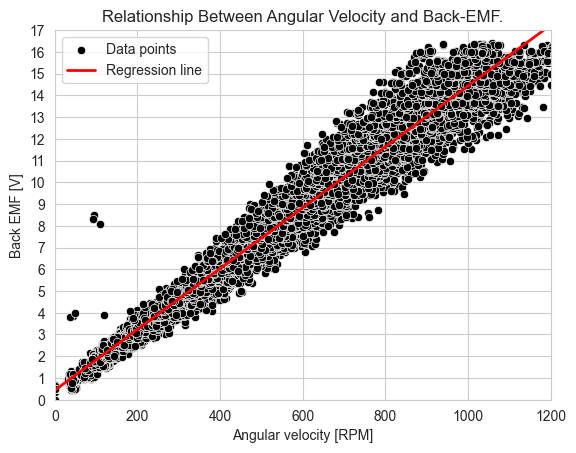

In [22]:
# Extract relevant data from dataframe
x = np.array(motor_df['RPM'].values) # Extract predictor values
y = np.array(motor_df['V_E'].values) # Extract target values


# Linear regression in deviation form
## Calculate predictor in deviation form
x_mean = np.mean(x)
x_dev = x - x_mean

## Perform linear regression using linregress
slope, intercept, r_value, p_value, std_err = stats.linregress(x_dev, y)

## Calculate predicted values and residuals
y_pred = intercept + slope * x_dev
residuals = y_pred - y

## Calculate SS_e, S_e^2, S_e and R^2
n = len(np.array(motor_df['V_E'].values))
SS_e = np.sum(residuals ** 2)
S_e_squared = SS_e / (n - 2)
S_e = np.sqrt(S_e_squared)
r_squared = r_value**2


## Print Results
print(" Linear Regression Analysis")
print("============================")
print("- Regression line:  y(x) = {:.2f} + {:.3f}x".format(intercept, abs(slope)))
print("- a = {:.4f}".format(intercept))
print("- b = {:.4f}".format(slope))
print("- SS_e = {:.4f}".format(SS_e))
print("- S_e^2 = {:.4f}".format(S_e_squared))
print("- S_e = {:.4f}".format(S_e))
print("- R^2 = {:.2f}".format(r_squared))


# Create Figure
## Plot datapoints
sns.scatterplot(x=x, y=y, color='black', label="Data points") 

## Plot regression line
sns.lineplot(x=x, y=y_pred, color='red', linewidth=2, label="Regression line")

## Plot settings
plt.xlabel('Angular velocity [RPM]')
plt.ylabel('Back EMF [V]')
plt.title('Relationship Between Angular Velocity and Back-EMF.')
plt.xlim(0, 1200)
plt.ylim(0, 17)
plt.yticks(range(0, 18, 1))
plt.legend()


# Save figure
file_name = "lin_reg_RPM_BEMF.pdf" # Plot name
file_path = os.path.join(figure_folder_name, file_name) # Generate file path
if SAVE:
    plt.savefig(file_path, format='pdf')


# Show plot
plt.show()

## Perform Inference
### Hyper Parameters

In [23]:
# Prior Hyperparameters
sigma_0 = 0
n_0 = 0

## Priors P0
v_0 = n_0 - 2
S_0 = sigma_0**2 * max(0, v_0)

## Print prior
print("Prior hyperparameters:")
print("- v_0 = {:.2f}".format(v_0))
print("- S_0 = {:.2f}".format(S_0))
print("")


# Posterior P1
## Calculate posterior
v_1 = v_0 + n
S_1 = S_0 + SS_e
if n_0 == 0 & S_0 == 0:
    sigma_1 = np.sqrt( SS_e / (n - 2) )
else:
    sigma_1 = np.sqrt( S_1 / v_1 )

## Print residuals
print("Posterior hyperparameters:")
print("- x_mean = {:.4f}".format(x_mean))
print("- beta_vec = [{:.4f}, {:.4f}]".format(intercept, slope))
print("- v_1 = {:.4f}".format(v_1))
print("- S_1 = {:.4f}".format(S_1))
print("- sigma_1 = {:.4f}".format(sigma_1))
print("- n = {:.4f}".format(n))


Prior hyperparameters:
- v_0 = -2.00
- S_0 = 0.00

Posterior hyperparameters:
- x_mean = 463.1348
- beta_vec = [6.9176, 0.0140]
- v_1 = 10614.0000
- S_1 = 7099.9009
- sigma_1 = 0.8179
- n = 10616.0000


### Posterior Probability Distributions
#### Print distributions

In [24]:
# Calculate missing parameters
SS_x = np.sum(x_dev**2)

# Print parameters
print("Parameters:")
print("v_1/2 = {:.4f}".format(v_1/2))
print("S_1 = {:.4f}".format(S_1/2))
print("alpha_* = {:.4f}".format(intercept))
print("sigma_1 * sqrt(1/n) = {:.4f}*10^3".format(sigma_1*np.sqrt(1/n) * 10**3))
print("beta = {:.4f}".format(intercept))
print("sigma_1 * sqrt(1/SS_x) = {:.4f}*10^5".format(sigma_1*np.sqrt(1/SS_x) * 10**5))
print("x_mean = {:.4f}".format(x_mean))
print("1/n = {:.4f}*10^5".format((1/n) * 10**5))
print("1/SS_x = {:.4f}10^10".format(((1/SS_x) * 10**10)))
print("")

# Print distributions
print("Distributions:")
print("tau ~ ({:.4f}, {:.4f})".format(v_1/2, S_1/2))
print("alpha_* ~ ({:.4f}, {:.4f}*10^3, {:.0f})".format(intercept, (sigma_1*np.sqrt(1/n) * 10**3), v_1))
print("beta ~ ({:.4f}, {:.4f}*10^5, {:.0f})".format(slope, (sigma_1*np.sqrt(1/SS_x) * 10**3), v_1))
print("y(x) ~ ({:.4f} + {:.4f}(x-{:.4f}), {:.4f} * sqrt[ ({:.4f}*10^5) + ({:.4f}*10^10)(x-{:.4f})^2 ], {:.0f})"
      .format(intercept, slope, x_mean, sigma_1, ((1/n) * 10**5), ((1/SS_x) * 10**10), x_mean, v_1))
print("Y_+(x) ~ ({:.4f} + {:.4f}(x-{:.4f}), {:.4f} * sqrt[ 1 + ({:.4f}*10^5) + ({:.4f}*10^10)(x-{:.4f})^2], {:.0f})"
      .format(intercept, slope, x_mean, sigma_1, ((1/n) * 10**5), ((1/SS_x) * 10**10), x_mean, v_1))

Parameters:
v_1/2 = 5307.0000
S_1 = 3549.9504
alpha_* = 6.9176
sigma_1 * sqrt(1/n) = 7.9379*10^3
beta = 6.9176
sigma_1 * sqrt(1/SS_x) = 2.3616*10^5
x_mean = 463.1348
1/n = 9.4197*10^5
1/SS_x = 8.337410^10

Distributions:
tau ~ (5307.0000, 3549.9504)
alpha_* ~ (6.9176, 7.9379*10^3, 10614)
beta ~ (0.0140, 0.0236*10^5, 10614)
y(x) ~ (6.9176 + 0.0140(x-463.1348), 0.8179 * sqrt[ (9.4197*10^5) + (8.3374*10^10)(x-463.1348)^2 ], 10614)
Y_+(x) ~ (6.9176 + 0.0140(x-463.1348), 0.8179 * sqrt[ 1 + (9.4197*10^5) + (8.3374*10^10)(x-463.1348)^2], 10614)


#### Plot Distributions


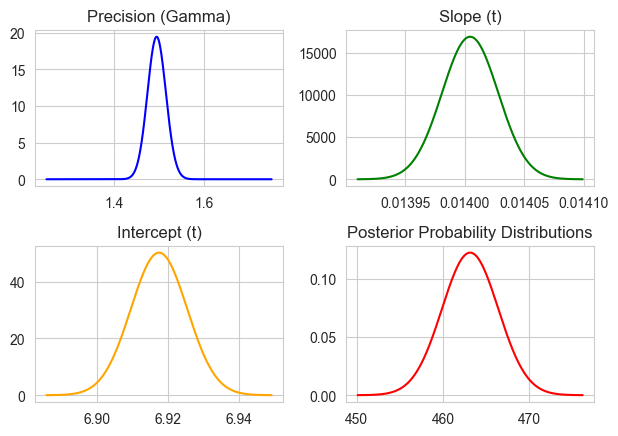

In [25]:
# Generate Values
## Generate x_values
x1_points = np.linspace(1.25, 1.75, 1000)  
x2_points = np.linspace(intercept - 4*sigma_1*np.sqrt(1/n), intercept + 4*sigma_1*np.sqrt(1/n), 1000)
x3_points = np.linspace(slope - 4*sigma_1*np.sqrt(1/SS_x), slope + 4*sigma_1*np.sqrt(1/SS_x), 1000)
x4_points = np.linspace(x_mean - 4*np.std(x, ddof=1) / np.sqrt(n), x_mean + 4*np.std(x, ddof=1) / np.sqrt(n), 1000)

## Precision
tau_gamma = stats.gamma.pdf(x1_points, v_1/2, scale=1/(S_1/2))

## Intercept
alpha_star_t = stats.t.pdf(x2_points, v_1, loc=intercept, scale=sigma_1*np.sqrt(1/n))

## Slope
beta_t = stats.t.pdf(x3_points, v_1, loc=slope, scale=sigma_1*np.sqrt(1/SS_x))

## Mean
mean_t = stats.t.pdf(x4_points, v_1, loc=x_mean, scale=np.std(x, ddof=1) / np.sqrt(n))


# Plotting
## Create figure
fig, axs = plt.subplots(2, 2, figsize=(6.3, 6.3/1.41))

## Precision subplot
axs[0, 0].plot(x1_points, tau_gamma, label='Precision (Gamma)', color='blue')
axs[0, 0].set_title('Precision (Gamma)')

## Intercept subplot
axs[1, 0].plot(x2_points, alpha_star_t, label='Intercept (t)', color='orange')
axs[1, 0].set_title('Intercept (t)')

## Slope subplot
axs[0, 1].plot(x3_points, beta_t, label='Slope (t)', color='green')
axs[0, 1].set_title('Slope (t)')

## Mean subplot
axs[1, 1].plot(x4_points, mean_t, label='Mean (t)', color='red')
axs[1, 1].set_title('Mean (t)')

# Figure settings
plt.title("Posterior Probability Distributions")
plt.grid(True)
plt.tight_layout()


# Save figure
file_name = "distributions.pdf" # Plot name
file_path = os.path.join(figure_folder_name, file_name) # Generate file path
if SAVE:
    plt.savefig(file_path, format='pdf')

# Display Figure
plt.show()

### Plotting Credibility and Predictive interval with regression line at 99% confidence.

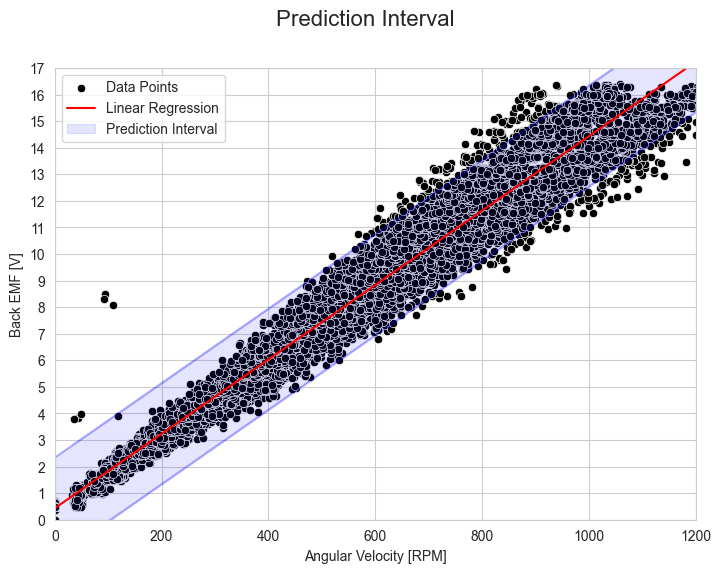

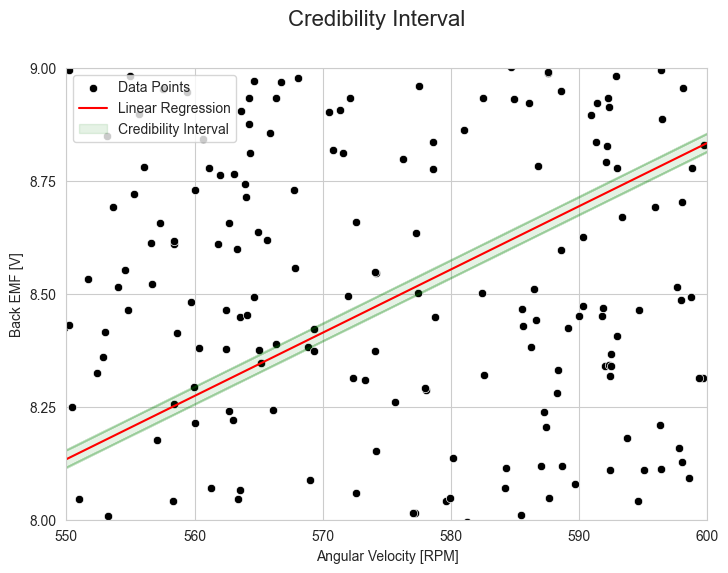

In [26]:
# Confidence level
P = 0.99
t_value = stats.t.ppf(P, n - 2)


# Calculate Margin of Error for credibility and prediction intervals
MoE_cred = t_value * sigma_1 * np.sqrt((1/n) + (1/SS_x)*(x-x_mean)**2)
MoE_pred = t_value * sigma_1 * np.sqrt(1 + (1/n) + (1/SS_x)*(x-x_mean)**2)


# Create Figure for prediction interval
figure_width_inches = 8.27
fig1, ax1 = plt.subplots(figsize=(figure_width_inches, figure_width_inches/1.41))
interval_fill_opacity = 0.10
interval_line_opacity = 0.25
fig1.suptitle("Prediction Interval", fontsize=16)


# Plot prediction interval
## Data points and regression line
sns.scatterplot(x=x, y=y, color='black', ax=ax1, label='Data Points')
sns.lineplot(x=x, y=y_pred, color='red', ax=ax1, label='Linear Regression')

## Intervals
ax1.fill_between(x, (y_pred-MoE_pred), (y_pred+MoE_pred), color='blue', alpha=interval_fill_opacity, label='Prediction Interval')
sns.lineplot(x=x, y=(y_pred-MoE_pred), color='blue', alpha=interval_line_opacity, ax=ax1)
sns.lineplot(x=x, y=(y_pred+MoE_pred), color='blue', alpha=interval_line_opacity, ax=ax1)

## Subplot settings
ax1.set(xlabel="Angular Velocity [RPM]", ylabel="Back EMF [V]")
ax1.legend(loc='upper left')
ax1.set_yticks(np.arange(0, 18, 1))
ax1.set_xlim(0, 1200)
ax1.set_ylim(0, 17)


# Save figure
file_name = "prediction_interval.pdf" # Plot name
file_path = os.path.join(figure_folder_name, file_name) # Generate file path
if SAVE:
    fig1.savefig(file_path, format='pdf')

# Display figure
plt.show()


# Create Figure for credibility interval
fig2, ax2 = plt.subplots(figsize=(figure_width_inches, figure_width_inches/1.41))
fig2.suptitle("Credibility Interval", fontsize=16)

# Plot credibility interval
## Data points and regression line
sns.scatterplot(x=x, y=y, color='black', ax=ax2, label='Data Points')
sns.lineplot(x=x, y=y_pred, color='red', ax=ax2, label='Linear Regression')

## Intervals
ax2.fill_between(x, (y_pred-MoE_cred), (y_pred+MoE_cred), color='green', alpha=interval_fill_opacity, label='Credibility Interval')
sns.lineplot(x=x, y=(y_pred-MoE_cred), color='green', alpha=interval_line_opacity,  ax=ax2)
sns.lineplot(x=x, y=(y_pred+MoE_cred), color='green', alpha=interval_line_opacity, ax=ax2)

## Subplot settings
ax2.set(xlabel="Angular Velocity [RPM]", ylabel="Back EMF [V]")
ax2.legend(loc='upper left')
ax2.set_yticks(np.arange(0, 18, 0.25))
ax2.set_xlim(550, 600)
ax2.set_ylim(8, 9)


# Save figure
file_name = "credibility_interval.pdf" # Plot name
file_path = os.path.join(figure_folder_name, file_name) # Generate file path
if SAVE:
    fig2.savefig(file_path, format='pdf')


# Display figure
plt.show()


### Calculate credibility and predictive interval for 800 RPM at 99% confidence.

In [27]:
# Calculate intervals at 800 RPM at 99% Confidence
# Calculate MoE
MoE_cred_800 = t_value * sigma_1 * np.sqrt((1/n) + (1/SS_x)*(800-x_mean)**2)
MoE_pred_800 = t_value * sigma_1 * np.sqrt(1 + (1/n) + (1/SS_x)*(800-x_mean)**2)

# Calculate intervals
cred_int_800 = [ (intercept + slope*(800-x_mean)) - MoE_cred_800, (intercept + slope*(800-x_mean)) + MoE_cred_800]
pred_int_800 = [ (intercept + slope*(800-x_mean)) - MoE_pred_800, (intercept + slope*(800-x_mean)) + MoE_pred_800]

# Print results
print("Credibility and Predictive interval at 800 RPM with 0.99 confidence.")
print("I_0.01 = ({:.4f}, {:.4f})".format(cred_int_800[0], cred_int_800[1]))
print("I_0.01^+ = ({:.4f}, {:.4f})".format(pred_int_800[0], pred_int_800[1]))


Credibility and Predictive interval at 800 RPM with 0.99 confidence.
I_0.01 = (11.6091, 11.6614)
I_0.01^+ = (9.7321, 13.5383)
